In [1]:
from minio import Minio
import s3fs
import os
import matplotlib.pyplot as plt
import xarray as xr
import pickle
import numpy as np
from sympl import get_constant
import metpy
from metpy.units import units
import matplotlib.pylab as pl
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms
from matplotlib.ticker import ScalarFormatter

fs = s3fs.S3FileSystem(
    client_kwargs={
        "endpoint_url": "http://192.168.1.237:9000"
    },
    key="d0d250b2541ac33f4660",
    secret="2fb32d964768bc94a3c0"
)
output_dir='/home/data/lab_project2/Steve/model_runs/aqua_planet/2/'
base_path = "abel-long-run/aqua-planet-modified/regridded-data/"
plot_path = '/home/data/lab_project2/Steve/model_runs/plotting/ap-plots/2/'
Rd = get_constant('gas_constant_of_dry_air', 'J kg^-1 K^-1')
Cp =\
    get_constant('heat_capacity_of_dry_air_at_constant_pressure',
                 'J kg^-1 K^-1')
g=get_constant('gravitational_acceleration',
                 'm s^-2')
DSE2T50 = 0.0007652254948802577
DSE2T35 = 0.0008546736412561125

/home/lab_project2/.conda/envs/xCDAT/lib/python3.13/site-packages/sympl/_core/dataarray.py:6: FutureWarning: xarray subclass DataArray should explicitly define __slots__
  class DataArray(xr.DataArray):


dsetot -1.2679250181802886e-15 4.367976826946014e-15
dseyca 1.549999447494119e-14 7.68713658271573e-15
dseyaa -5.438514294587766e-15 5.543865212426744e-15
dsexac 8.872630801033822e-17 3.507320502970893e-15
dsexaa 1.0757740312011603e-16 3.774313824058645e-15
dsez -1.197678355338209e-14 6.263144402612952e-15
dseres 2.68525669805605e-15 4.6049732810713715e-15
dsetot -1.8355486446697917e-16 2.8594683978893863e-15
dseyca 9.195647516743504e-15 5.425597990422368e-15
dseyaa -3.048565984514669e-15 4.2361251091614706e-15
dsexac -1.889700158815007e-16 3.068380764892122e-16
dsexaa -3.3354610609966735e-16 2.209628542528092e-15
dsez -5.8633060406061624e-15 3.4111427710544644e-15
dseres 1.1927683115139451e-15 2.6420772668971456e-15
dsetot 3.2119261302212635e-16 3.3948573621869774e-15
dseyca 8.616956352358443e-15 6.78721906379615e-15
dseyaa -3.6356027233864565e-15 4.696416904370579e-15
dsexac -7.459457715590212e-17 3.681990345614676e-15
dsexaa 6.389703597453406e-16 3.8841760534458634e-15
dsez -5.65625

/tmp/ipykernel_735888/1621457879.py:131: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax1.annotate("50N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_735888/1621457879.py:132: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax2.annotate("35N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_735888/1621457879.py:133: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax3.annotate("50N - Low intensity",xy=(0.5725,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_735888/16

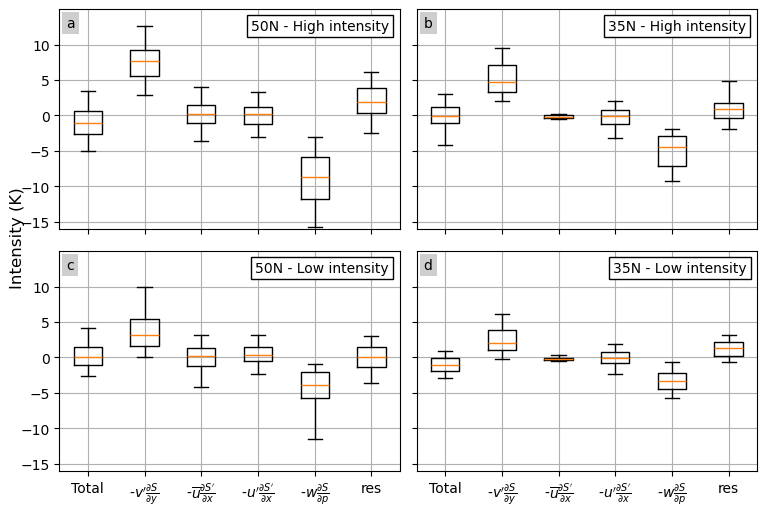

In [6]:
with open(output_dir+'dse_rey_HI_50', 'rb') as f:
    rey_HI_50 = pickle.load(f)

with open(output_dir+'dse_rey_HI_35', 'rb') as f:
    rey_HI_35 = pickle.load(f)

with open(output_dir+'dse_rey_LI_50', 'rb') as f:
    rey_LI_50 = pickle.load(f)

with open(output_dir+'dse_rey_LI_35', 'rb') as f:
    rey_LI_35 = pickle.load(f)
    
##########################F#################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, hspace=0.1, wspace=0.05)
fig=pl.figure(figsize=(9,6))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 
ax3 = pl.subplot(gs[1, 0])
ax4 = pl.subplot(gs[1, 1])
low_lim, up_lim = -16, 15

######################### high intensity lat 50 ###########################
dse_master=rey_HI_50
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)

# combining dseyca and dseyaa
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x.pop(2)
x = [ (DSE2T50 * np.array(arr)).tolist() for arr in x ]
ax1.boxplot(x, showfliers=False, whis=(5,95))
ax1.grid()
ax1.set_xticklabels([])
#ax1.yaxis.set_major_formatter(formatter)
ax1.autoscale(axis='y')
ax1.set_ylim(low_lim,up_lim)
ax1.yaxis.get_major_locator().set_params(prune='both')
set_label(fig, ax1, 'a')


####################### high intensity lat 35 #############################
dse_master=rey_HI_35
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)
#x = np.array(x)
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x.pop(2)
x = [ (DSE2T35 * np.array(arr)).tolist() for arr in x ]
ax2.boxplot(x, showfliers=False, whis=(5,95))
ax2.grid()
ax2.set_xticklabels([])
#ax2.yaxis.set_major_formatter(formatter)
ax2.autoscale(axis='y')
ax2.set_ylim(low_lim, up_lim)
ax2.yaxis.get_major_locator().set_params(prune='both')
set_label(fig,ax2, 'b')
ax2.set_yticklabels([])

###################### low intensity lat 50 ###############################
dse_master=rey_LI_50
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)
#x = np.array(x)
x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x.pop(2)
x = [ (DSE2T50 * np.array(arr)).tolist() for arr in x ]
ax3.boxplot(x, showfliers=False, whis=(5,95))
ax3.grid()
ax3.autoscale(axis='y')
ax3.set_ylim(low_lim, up_lim)
ax3.yaxis.get_major_locator().set_params(prune='both')
#ax3.yaxis.set_major_formatter(formatter)
set_label(fig,ax3, 'c')
ax3.set_xticks([1, 2, 3, 4, 5, 6], ['Total', r'-$v^\prime\frac{\partial S}{\partial y}$',
                                r'-$\overline{u}\frac{\partial S^\prime}{\partial x}$',
                                r'-$u^\prime\frac{\partial S^\prime}{\partial x}$',
                                r'-$w\frac{\partial S}{\partial p}$',
                                'res'])

###################### low intensity lat 35 ###############################
dse_master=rey_LI_35
x=[]
chk=[]
for d in ['dsetot','dseyca','dseyaa','dsexac','dsexaa','dsez','dseres']:
    chk.append( np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18)
    x.append(([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]]))
    print(d, np.mean([np.mean(np.cumsum(np.insert(e, 0, 0))) for e in dse_master[d]])/1e18, np.std([e.cumsum().mean().item() for e in dse_master[d]])/1e18)

x[1] = (np.array(x[1])+np.array(x[2])).tolist()
x.pop(2)
x = [ (DSE2T35 * np.array(arr)).tolist() for arr in x ]
ax4.boxplot(x, showfliers=False, whis=(5,95))
ax4.grid()
#ax4.yaxis.set_major_formatter(formatter)
ax4.autoscale(axis='y')
ax4.set_ylim(low_lim, up_lim)
set_label(fig,ax4, 'd')
ax4.set_yticklabels([])
ax4.yaxis.get_major_locator().set_params(prune='both')
ax4.set_xticks([1, 2, 3, 4, 5, 6], ['Total', r'-$v^\prime\frac{\partial S}{\partial y}$',
                                r'-$\overline{u}\frac{\partial S^\prime}{\partial x}$',
                                r'-$u^\prime\frac{\partial S^\prime}{\partial x}$',
                                r'-$w\frac{\partial S}{\partial p}$',
                                'res'])


ax1.annotate("50N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax2.annotate("35N - High intensity",xy=(0.56,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax3.annotate("50N - Low intensity",xy=(0.5725,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax4.annotate("35N - Low intensity",xy=(0.575,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
fig.supylabel("Intensity (K)", fontsize=12, x=0.07)

fig.savefig(plot_path+'4.pdf', bbox_inches='tight')
#fig.savefig(plot_path+'4.jpg',dpi=600, bbox_inches='tight')